---
title: "Patching — geometry gallery (Rectangular, SphericalCap, KNN, …)"
---

# Patching geometries gallery

`SpatialPatcher` ships five `Geometry` types, each dispatching on the
`Domain` it gets handed. This notebook walks through the four
canonical (Geometry × Domain) pairings against **three real
substrates** — one per data shape:

1. `SpatialRectangular` × `RasterDomain` — tiling a Sentinel-2 chip.
2. `SpatialSphericalCap` × `GridDomain` — geodesic cap on a lat/lon
   grid (1° resolution global cell index).
3. `SpatialKNNGraph` × `PointDomain` — k-nearest GBIF occurrence
   points (California live oak, *Quercus agrifolia*).
4. `SpatialRadiusGraph` × `PointDomain` — same point cloud,
   within-radius neighbourhood.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from geopatcher import (
    GridDomain,
    PointDomain,
    RasterField,
    SpatialBoxcar,
    SpatialByIndex,
    SpatialExplicit,
    SpatialKNNGraph,
    SpatialPatcher,
    SpatialRadiusGraph,
    SpatialRectangular,
    SpatialRegularStride,
    SpatialSphericalCap,
)
from scipy.spatial import cKDTree

from geostack import LAKE_TAHOE_BBOX, load_gbif_points, load_s2_chip

## 1. `SpatialRectangular × RasterDomain` — tiling a real Sentinel-2 chip

The Lake Tahoe BGRN chip's NIR band, downsampled to 256×256 so the
patch overlay reads at a glance.

crop shape: (256, 256)


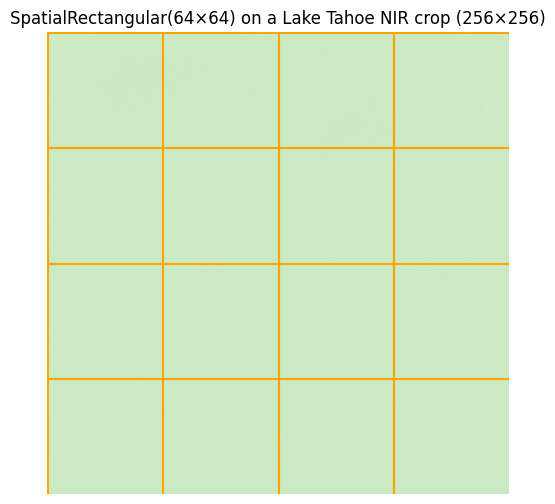

In [2]:
gt_bgrn = load_s2_chip(bbox=LAKE_TAHOE_BBOX)
nir_full = np.asarray(gt_bgrn)[3].astype("float32") * 1e-4
# Take a 256×256 corner crop for visual clarity.
crop = nir_full[600:856, 200:456]
print(f"crop shape: {crop.shape}")

import rasterio
from georeader.geotensor import GeoTensor

crop_transform = gt_bgrn.transform * rasterio.Affine.translation(200, 600)
field = RasterField(
    GeoTensor(
        values=crop,
        transform=crop_transform,
        crs=gt_bgrn.crs,
        fill_value_default=0.0,
    )
)

patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(64, 64)),
    sampler=SpatialRegularStride(step=64),
    window=SpatialBoxcar(),
    aggregation=SpatialByIndex(),
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(crop, cmap="Greens", vmin=0, vmax=0.5)
for patch in patcher.split(field):
    w = patch.indices
    ax.add_patch(
        plt.Rectangle(
            (w.col_off, w.row_off),
            w.width,
            w.height,
            fill=False,
            edgecolor="orange",
            linewidth=1.5,
        )
    )
ax.set_title("SpatialRectangular(64×64) on a Lake Tahoe NIR crop (256×256)")
ax.axis("off")
plt.show()

## 2. `SpatialSphericalCap × GridDomain` — geodesic neighbourhoods

A 1° regular lat/lon grid spanning ±60° latitude is a faithful
stand-in for any global gridded product (ERA5, NOAA SST, MODIS
climate). The cap shrinks in *pixel terms* as latitude increases
because grid cells are smaller meridionally at high latitudes —
something a naive raster patcher would never see.

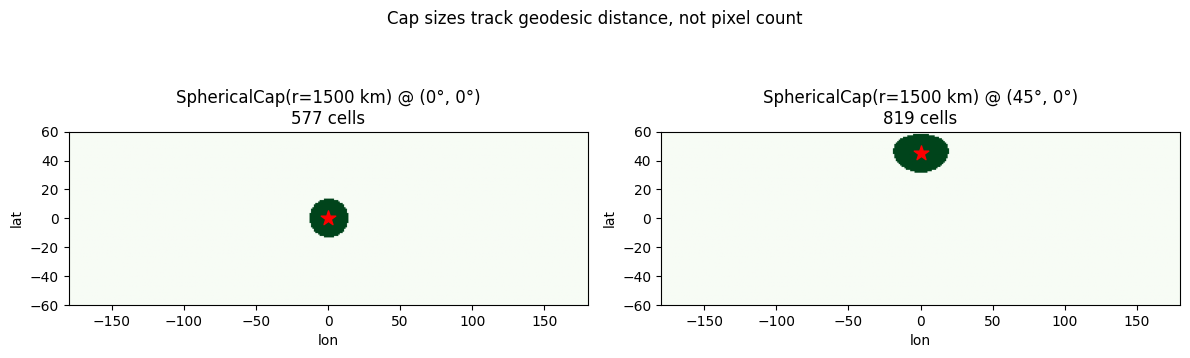

In [3]:
lat = np.arange(-60.0, 60.5, 1.0)  # 121 cells
lon = np.arange(-180.0, 180.5, 1.0)  # 361 cells
grid = GridDomain(coords={"lat": lat, "lon": lon})

cap = SpatialSphericalCap(radius_km=1500.0)
anchors = [(0.0, 0.0), (45.0, 0.0)]  # equator + mid-latitude

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (a_lat, a_lon) in zip(axes, anchors, strict=True):
    neigh = cap.neighborhood(grid, anchor=(a_lat, a_lon))
    mask = np.zeros((len(lat), len(lon)), dtype=bool)
    mask[neigh[:, 0], neigh[:, 1]] = True
    ax.imshow(
        mask,
        origin="lower",
        cmap="Greens",
        extent=(lon[0], lon[-1], lat[0], lat[-1]),
    )
    ax.scatter([a_lon], [a_lat], c="red", marker="*", s=120, zorder=3)
    ax.set_title(f"SphericalCap(r=1500 km) @ ({a_lat:.0f}°, {a_lon:.0f}°)\n{len(neigh)} cells")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
plt.suptitle("Cap sizes track geodesic distance, not pixel count")
plt.tight_layout()
plt.show()

## 3. `SpatialKNNGraph × PointDomain` — k-nearest GBIF occurrences

500 GBIF occurrence records for **California live oak** (*Quercus
agrifolia*, taxon key 5285750) across California. Each point is a
real observation report — the cluster structure (coastal ranges,
valley centres, sparse desert) is the true ecological signal.

GBIF: 300 occurrence points for Q. agrifolia


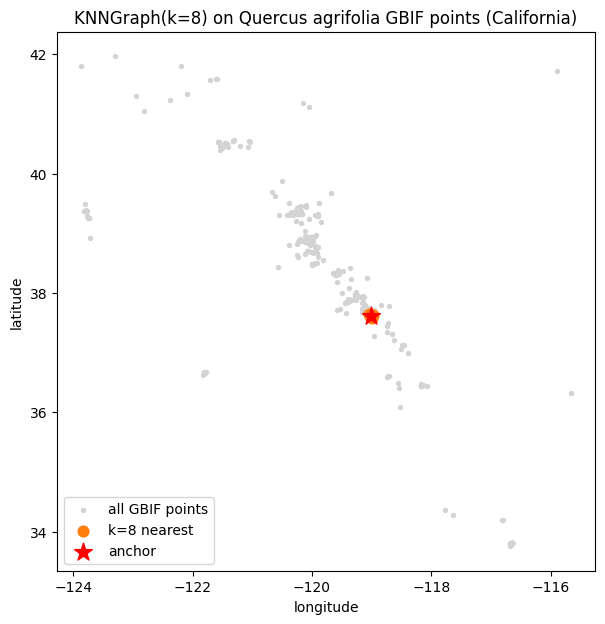

In [4]:
gbif_df = load_gbif_points(species_key=5285750, limit=500)
print(f"GBIF: {len(gbif_df)} occurrence points for Q. agrifolia")
pts = np.column_stack([gbif_df.geometry.x.values, gbif_df.geometry.y.values])
point_domain = PointDomain(coords=pts, kdtree=cKDTree(pts))

knn = SpatialKNNGraph(k=8)
anchor = pts[len(pts) // 2]  # an arbitrary record near the median
neigh_knn = knn.neighborhood(point_domain, anchor=anchor)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(pts[:, 0], pts[:, 1], c="lightgray", s=8, label="all GBIF points")
ax.scatter(
    pts[neigh_knn, 0], pts[neigh_knn, 1],
    c="C1", s=60, label=f"k={len(neigh_knn)} nearest",
)
ax.scatter([anchor[0]], [anchor[1]], c="red", s=180, marker="*", label="anchor")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("KNNGraph(k=8) on Quercus agrifolia GBIF points (California)")
ax.legend()
ax.set_aspect("equal")
plt.show()

## 4. `SpatialRadiusGraph × PointDomain` — within-radius neighbours

Same point cloud, but the geometry asks "every occurrence within
0.25° of the anchor" instead of "the k nearest". The neighbourhood
size now adapts to the local point density — sparse desert anchors
return few neighbours, dense coastal anchors return many.

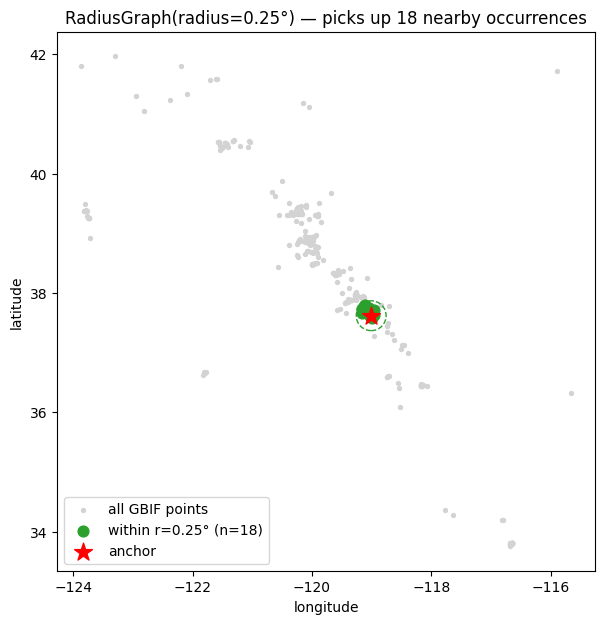

In [5]:
radius = SpatialRadiusGraph(radius=0.25)  # ~28 km at this latitude
neigh_radius = radius.neighborhood(point_domain, anchor=anchor)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(pts[:, 0], pts[:, 1], c="lightgray", s=8, label="all GBIF points")
ax.scatter(
    pts[neigh_radius, 0], pts[neigh_radius, 1],
    c="C2", s=60, label=f"within r=0.25° (n={len(neigh_radius)})",
)
ax.scatter([anchor[0]], [anchor[1]], c="red", s=180, marker="*", label="anchor")
ax.add_patch(plt.Circle(anchor, 0.25, fill=False, edgecolor="C2", linestyle="--"))
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"RadiusGraph(radius=0.25°) — picks up {len(neigh_radius)} nearby occurrences")
ax.legend()
ax.set_aspect("equal")
plt.show()

## 5. `ByIndex` aggregation — irregular graph patching

When patches don't form a dense grid (KNN, RadiusGraph, …) the
natural aggregation is `SpatialByIndex`, which returns a
``{anchor: result}`` dict rather than trying to reconstruct a global
field. We materialise 3 KNN-graph patches anchored at three
different GBIF points.

In [6]:
graph_patcher = SpatialPatcher(
    geometry=SpatialKNNGraph(k=5),
    sampler=SpatialExplicit(anchors_=[tuple(p) for p in pts[:3]]),
    window=SpatialBoxcar(),
    aggregation=SpatialByIndex(),
)

# A tiny point-Field adapter so the patcher can pull data per anchor.
class _PointField:
    domain = point_domain

    def select(self, idx):
        return pts[idx]

    def with_data(self, x):
        return x


patches = list(graph_patcher.split(_PointField()))
print(f"materialised {len(patches)} graph patches:")
for p in patches:
    anchor_lat, anchor_lon = p.anchor
    print(f"  anchor=({anchor_lat:6.3f}, {anchor_lon:6.3f})  k-neighbours={len(p.data)}")

materialised 3 graph patches:
  anchor=(-118.566, 36.486)  k-neighbours=5
  anchor=(-119.899, 39.290)  k-neighbours=5
  anchor=(-123.776, 39.372)  k-neighbours=5


## Recap — when to reach for which geometry

| Geometry | Domain | Use it for |
|---|---|---|
| `SpatialRectangular` | `RasterDomain` | Tiled raster inference — the bread-and-butter case. |
| `SpatialSphericalCap` | `GridDomain` | Cells on a global lat/lon grid (ERA5, GHCN, climate model output). |
| `SpatialKNNGraph` | `PointDomain` | "k nearest sensors / observations / waypoints" — fixed neighbourhood size. |
| `SpatialRadiusGraph` | `PointDomain` | "every record within R" — density-adaptive neighbourhood size. |
| `SpatialPolygonIntersection` | `RasterDomain` / `VectorDomain` | Per-polygon zonal stats. |

All five share the same `(Domain, anchor) -> indices` contract, so
the rest of the `SpatialPatcher` (sampler / window / aggregation)
stays unchanged when you swap one out.